In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sbn

In [5]:
df = pd.read_csv("combined_employee_dataset_1.csv")

In [6]:
df.head()

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor


In [7]:
df.tail()

,age,years_experience,education_level,department,performance_score,performance_category
786,21,19,Bachelor,Sales,9,Very Good
787,25,4,Master,Finance,4,Average
788,47,35,Bachelor,Finance,6,Good
789,47,17,High School,Sales,1,Poor
790,39,28,Bachelor,Sales,9,Very Good


In [8]:

df.shape

(791, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   791 non-null    int64 
 1   years_experience      791 non-null    int64 
 2   education_level       791 non-null    object
 3   department            791 non-null    object
 4   performance_score     791 non-null    int64 
 5   performance_category  791 non-null    object
dtypes: int64(3), object(3)
memory usage: 37.2+ KB


In [10]:
df.describe()

,age,years_experience,performance_score
count,791.000000,791.000000,791.000000
mean,39.867257,21.031606,5.495575
std,11.867681,11.467412,2.927766
min,20.000000,1.000000,1.000000
25%,29.000000,11.000000,3.000000
50%,41.000000,22.000000,5.000000
75%,51.000000,32.000000,8.000000
max,59.000000,39.000000,10.000000


In [11]:
df.isnull().sum()

age                     0
years_experience        0
education_level         0
department              0
performance_score       0
performance_category    0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)
df.fillna(0,inplace=True)

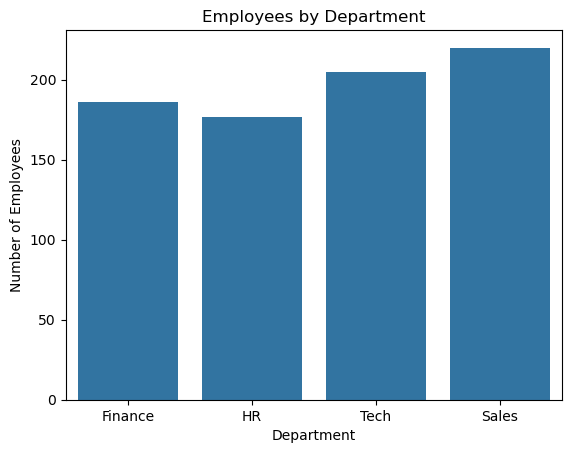

In [13]:
sbn.countplot(
    data=df,
    x='department'
)
plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

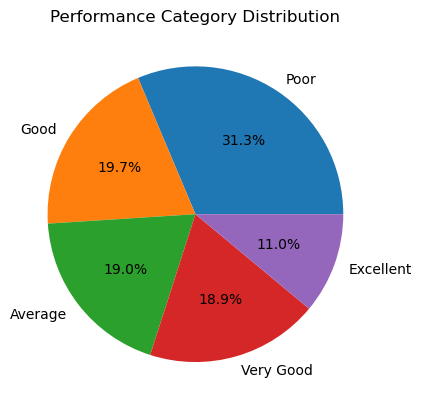

In [16]:
performance_counts = df['performance_category'].value_counts()  #accesses specific column and .valuecounts(): this function counts how many times each unique value appears in that column
plt.pie(
    performance_counts,    #result stored in variable : peformance counts
    labels=performance_counts.index, #assigns name to each slice
    autopct='%1.1f%%'     #automatically calculates and displays percentage
)
plt.title("Performance Category Distribution")     #Heading
plt.show()

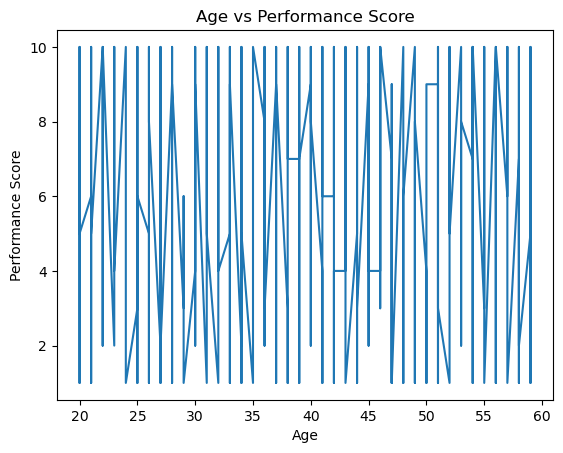

In [17]:
#Pandas and matplotlib libraries used to visualize relationship between age and performance score
sorted_df = df.sort_values("age")   #sorts original dataframe by the age column in ascending order(necessary for line plots to ensure the line connects points) 
plt.plot(
    sorted_df['age'],
    sorted_df['performance_score']
)
plt.title("Age vs Performance Score")
plt.xlabel("Age")
plt.ylabel("Performance Score")
plt.show()

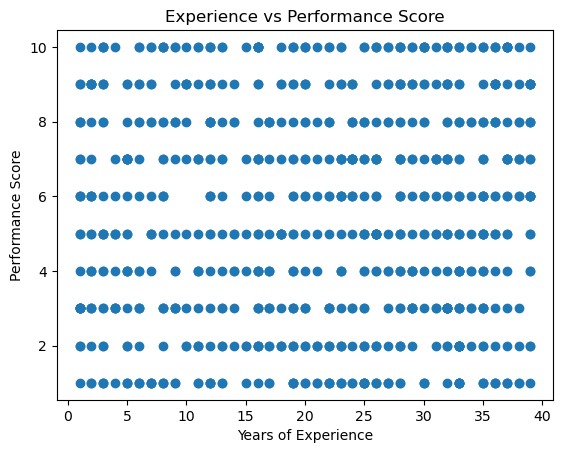

In [21]:
plt.scatter(
    df['years_experience'],
    df['performance_score']
)
plt.title("Experience vs Performance Score")
plt.xlabel("Years of Experience")
plt.ylabel("Performance Score")
plt.show()

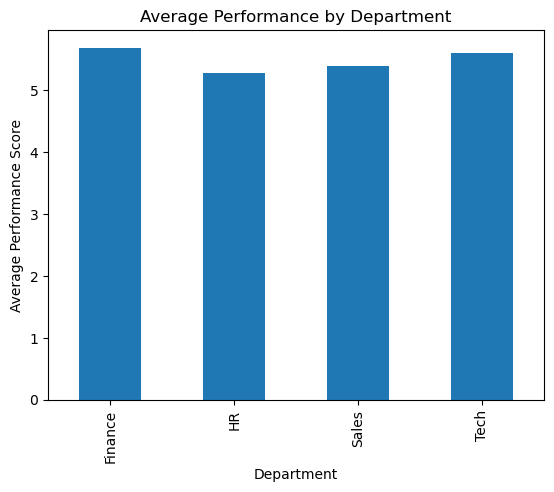

In [46]:
dept_perf = df.groupby('department')['performance_score'].mean()
dept_perf.plot(kind='bar')
plt.title("Average Performance by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.show()

In [47]:
df

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor
...,...,...,...,...,...,...
786,21,19,Bachelor,Sales,9,Very Good
787,25,4,Master,Finance,4,Average
788,47,35,Bachelor,Finance,6,Good
789,47,17,High School,Sales,1,Poor


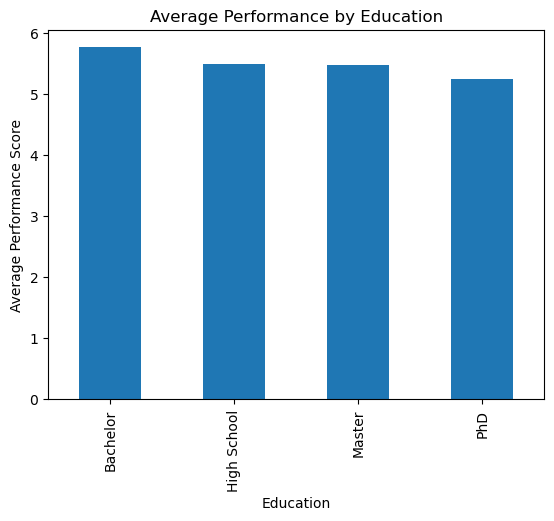

In [48]:
dept_perf = df.groupby('education_level')['performance_score'].mean()
dept_perf.plot(kind='bar')
plt.title("Average Performance by Education")
plt.xlabel("Education")
plt.ylabel("Average Performance Score")
plt.show()

In [49]:
mask = df['department'].str.contains('Finance',case=False)

In [50]:
mask

0       True
1      False
2      False
3      False
4       True
       ...  
786    False
787     True
788     True
789    False
790    False
Name: department, Length: 788, dtype: bool

In [51]:
finance_data = df[mask]

In [52]:
finance_data

,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
4,40,36,PhD,Finance,2,Poor
7,42,7,PhD,Finance,10,Excellent
22,52,27,Bachelor,Finance,1,Poor
28,35,27,Master,Finance,1,Poor
...,...,...,...,...,...,...
759,20,33,PhD,Finance,3,Poor
770,51,12,Master,Finance,3,Poor
780,55,21,Master,Finance,4,Average
787,25,4,Master,Finance,4,Average


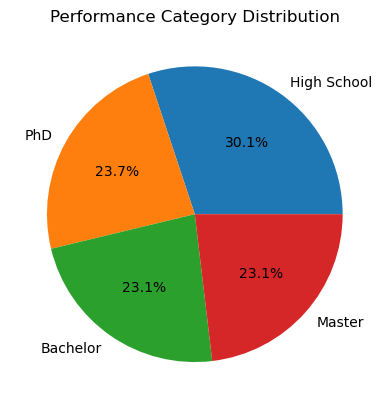

In [56]:
finance_data['education_level'].value_counts().plot(kind='pie', autopct= '%1.1f%%', label='')
plt.title("finance data")     #Heading
plt.title("Performance Category Distribution")     #Heading
plt.show()

